In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Import cleaned dataset
df = pd.read_csv(r"C:\Users\owner\Downloads\wrangledGES.csv")

In [2]:
# change all degree names to lowercase to simplify matching process
df['degree'] = df['degree'].str.lower() 

# display format of dataset
df.head(2)

,year,university,school,degree,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile
0,2013,NTU,College of Business (Nanyang Business School),accountancy and business,97.4,96.1,3701,3200,3727,3350,2900,4000
1,2013,NTU,College of Business (Nanyang Business School),accountancy (3-yr direct honours programme),97.1,95.7,2850,2700,2938,2700,2700,2900


In [3]:
# Function for finding specific degrees from each university
def find_degree(name, uni=df['university'].unique()):
    result = {}
    for u in uni:
        u_deg = pd.Series(df[(df['degree'].str.contains(name)) & (df['university']==u)]['degree'].unique())
        result[u] = u_deg
        
    return pd.DataFrame(result)

# Overall metrics

In [4]:
# Plots a barchart of the top 4 and bottom 4 degrees using a specified metric
def stat_compare(degrees, metric='employment_rate_ft_perm', uni=df['university'].unique()):
    labels, values = [], []
    
    # fill up labels and values lists
    for d in degrees:
        for u in uni:
            # search for degree from dataset, group by year and find the mean of all instances in the same year
            result = df.loc[(df['university'] == u) & (df['degree'].str.contains(d, regex=False))].groupby('year', as_index=False)[metric].mean().round(2)
            result = result[result['year']==2025]

            # if degree or year is not found, continue to the next iteration
            if result.empty:
                continue

            # labels will contain degree and the university it is from
            labels.append(u + ' ' + d)
            values.append(result[metric].values[0])
            
    # iterate through values and labels lists in parallel and sort in descending order
    pairs = sorted(zip(values, labels), reverse=True)

    # find top 4 degrees
    top = pairs[:4]

    # find bottom 4 degrees
    bottom = pairs[-4:]

    #  collect selected degrees
    if len(pairs) <= 8:
        selected = pairs
    else:
        selected = top + bottom
    values, labels = zip(*selected)

    # make histogram plot
    fig, ax = plt.subplots(figsize=(14, 4))
    bars = ax.bar(labels, values, width=0.5)
    ax.set_title(f'{metric.replace("_", " ")}')
    ax.set_ylabel(f'{metric.replace("_", " ")}')
    plt.tight_layout()
    plt.xticks(rotation=90)
    plt.show()

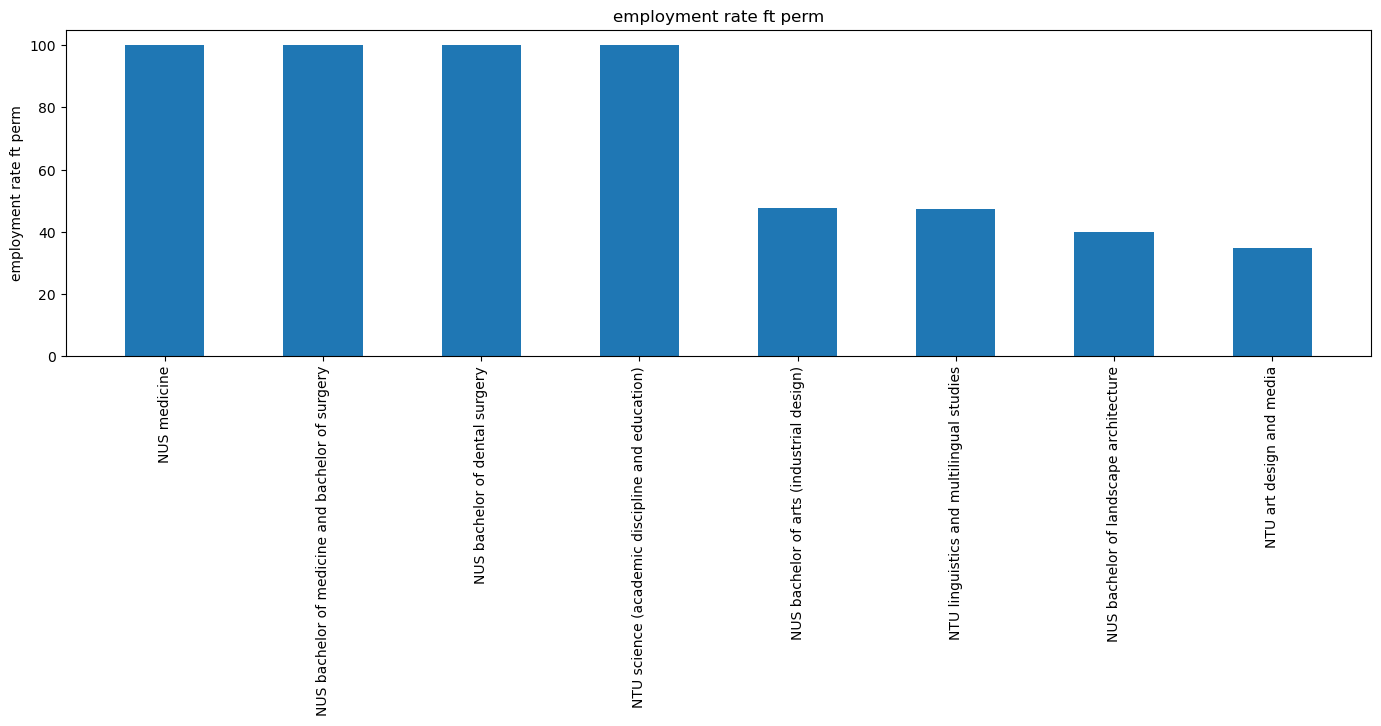

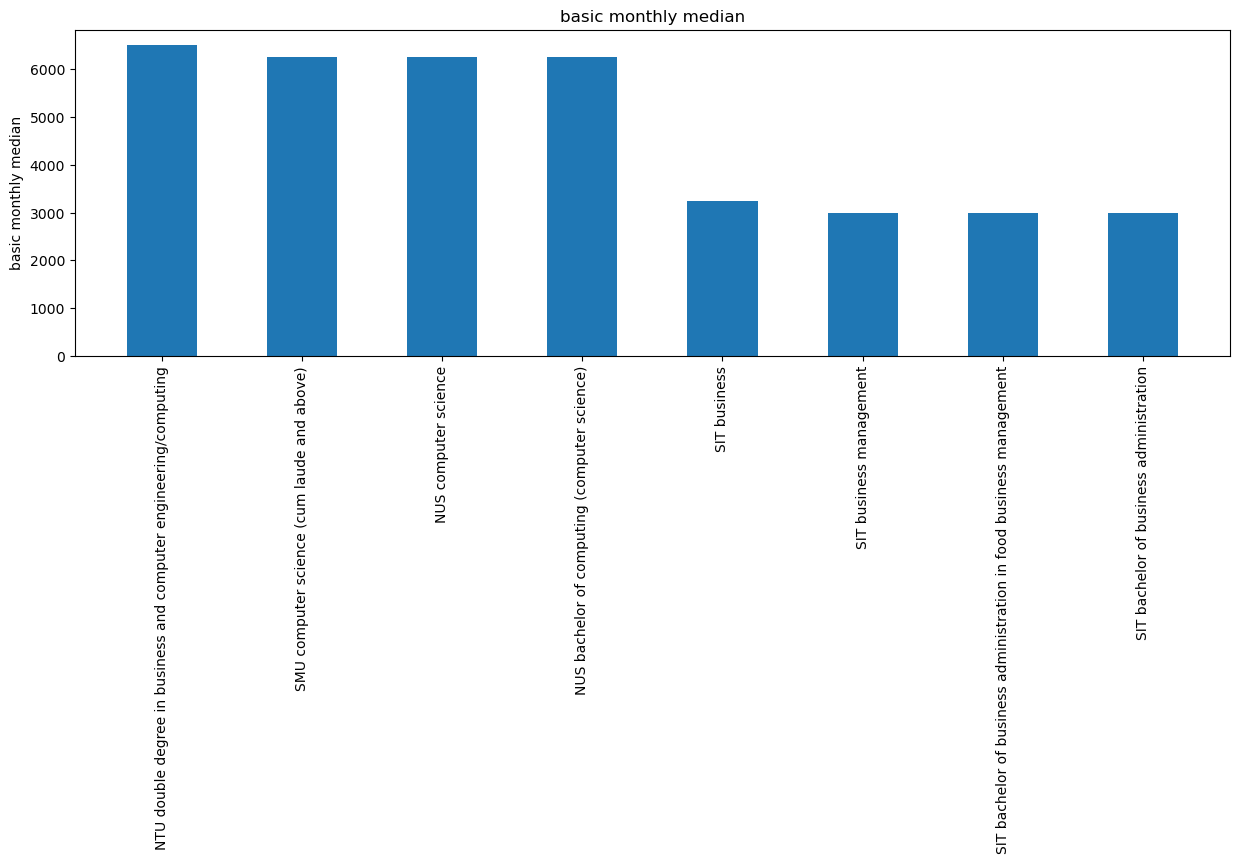

In [5]:
deg = df['degree'].unique()
stat_compare(deg)
stat_compare(deg, metric='basic_monthly_median')

### Insights
- **Education, medicine, dental surgery are among the most employable**

Medicine and dental surgery are critical, high-demand healthcare degrees in Singapore. These degrees are highly selective and lead to strong, stable career pathways in both public and private healthcare institutions. Demand is structurally supported by Singapore’s rapidly ageing population and persistent shortages in healthcare manpower. As a result, graduates from these fields consistently achieve very high employability outcomes.

Similarly, education graduates benefit from steady demand, as the supply of qualified teachers is carefully managed and often limited. Teaching remains an essential public service, with ongoing needs across primary, secondary, and tertiary levels. This creates a stable pipeline of job opportunities, making education one of the more reliable fields in terms of employment prospects.

- **Computer science degrees are most lucrative**

In recent years, many students have been drawn to computer science degrees, influenced by strong salary outcomes and widely shared discussions on platforms like Reddit. The COVID-19 pandemic accelerated digitalisation across industries, significantly increasing demand for tech talent such as software developers and engineers. This demand was further amplified by the early wave of AI adoption, which required specialised skills to build and manage emerging systems.

However, the initial shortage of talent and the resulting high salaries has since attracted a surge of students into these fields. While computer science graduates still command relatively high pay, growing labour supply and advancements in AI may reduce demand for certain entry-level roles. Consequently, salary growth is likely to moderate.

- **Niche and arts related degrees rank at the bottom**

Niche and arts-related degrees consistently rank lower in employability and salary outcomes compared to more professionally oriented fields in Singapore. These programmes often lead to more fragmented career pathways, with graduates entering a wider variety of industries that may not be directly aligned with their field of study. As such employment outcomes tend to be more variable, with higher rates of unemployment or delayed job placement.

Text(0.5, 0.98, 'Overall job statistics')

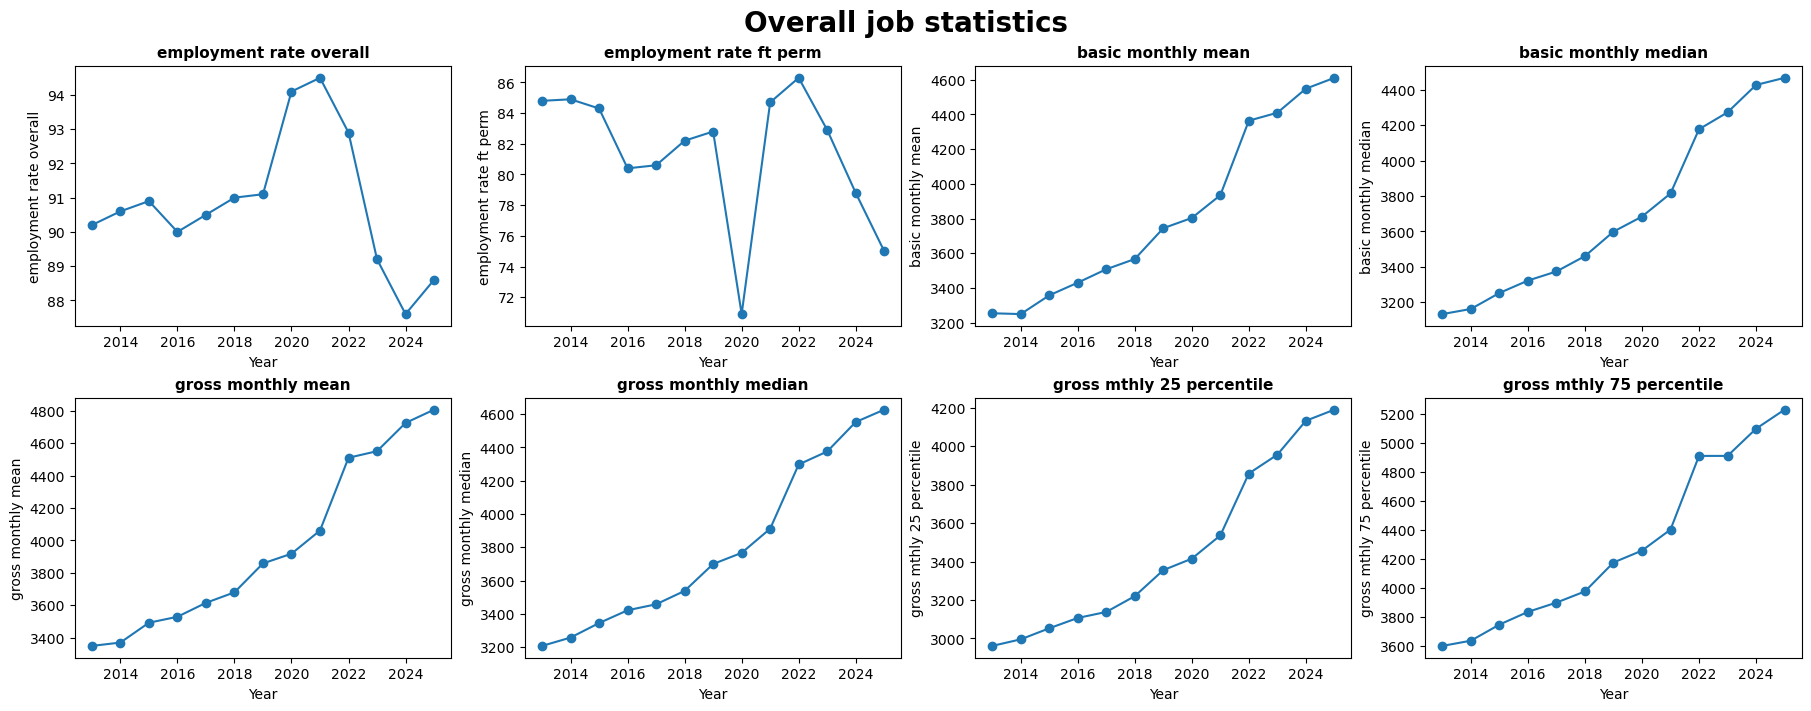

In [6]:
# plot all metrics
df_grouped = df.groupby('year')[df.columns[4:]].mean().round(1).reset_index()

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

fig, axes = plt.subplots(2, 4, figsize=(18, 7), constrained_layout=True)
metrics = list(df_grouped.columns[1:])

for ax, m in zip(axes.flat, metrics):
    ax.plot(df_grouped['year'], df_grouped[m], marker='o')
    ax.set_xlabel('Year')
    ax.set_ylabel(m.replace('_', ' '))
    ax.set_title(m.replace('_', ' '), fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))

fig.suptitle('Overall job statistics', fontsize=20, fontweight='bold')

#### Insights
- **Sharp fall in employement rates from 2022**

AI is increasingly automating routine entry-level tasks such as basic analysis, coding assistance, and administrative work. This reduces the number of roles traditionally used as stepping stones for fresh graduates. Employers now expect graduates to contribute at a higher level from the start, often requiring familiarity with AI tools. As a result, those without practical or technical skills face greater difficulty entering the workforce.

Many companies shift lower-value functions, such as back-office operations and support roles, to countries with cheaper labour. This helps firms reduce costs but also removes a layer of entry-level jobs within Singapore. The roles that remain tend to be more specialised and demand prior experience or advanced skills. This creates a barrier for fresh graduates trying to secure their first job. 

Global economic volatility makes businesses more cautious about expanding their workforce. Companies may freeze hiring, reduce graduate intake, or delay recruitment plans to manage risks. This leads to fewer opportunities and longer job search durations for new graduates.

The number of university graduates has increased significantly over time due to expanded access to higher education. However, the growth in suitable graduate-level jobs has not kept pace with this rise. This imbalance creates intense competition among graduates for a limited number of roles. Hence, some take longer to find jobs or accept positions that do not fully match their qualifications. According to a recent Straits Times article, nearly 1 in 5 Singaporean workers were overqualified in 2025.

- **Salaries have been rising steadily**

In a city with high cost of living, it is important for companies to raise salaries in line with inflation to retain and attract talent.

Moreover despite overall employment challenges, certain skill segments such as cybersecurity and healthcare face shortages. Employers compete more aggressively for these graduates, bidding up starting salaries. This results in a widening dispersion where top candidates command significantly higher pay, lifting aggregate salary statistics.

# Metrics by industry

In [7]:
# function to plot subplots of a list of degrees of a specified metric against year

import math

def plot_subplots(degrees, metric='employment_rate_overall', uni=df['university'].unique()):
    # plan subplot layout
    n = len(degrees)
    ncols = min(n, 3) # favour columns of 3 for large datasets
    nrows = math.ceil(n / ncols)

    # create subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), constrained_layout=True)

    # make list of axes of subplots
    if n == 1:
        axes = [axes]
    else:
        axes = list(axes.flat)

    # iterate in parallel through axes and degrees list to plot each subplot
    for ax, degree in zip(axes, degrees):
        for u in uni:
            result = df.loc[(df['university'] == u) & (df['degree'].str.contains(degree, na=False))].groupby('year', as_index=False)[metric].mean()                                    
            # the problem is the same degree have different names within each university so I just grouped and averaged them out to simplify things
            
            ax.plot(result['year'], result[metric], marker='o', label=u)

        # set plot and axis aesthetics
        ax.set_title(degree, fontsize=11, fontweight='bold')
        ax.set_xlabel('Year')
        ax.set_ylabel(metric.replace('_', ' ').title())
        ax.legend(loc='best')
        ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))

    # remove unused axes
    for ax in axes[n:]: 
        ax.set_visible(False)

    fig.suptitle(metric.replace('_', ' ').title(), fontsize=20, fontweight='bold')
    plt.show()

## Tech jobs

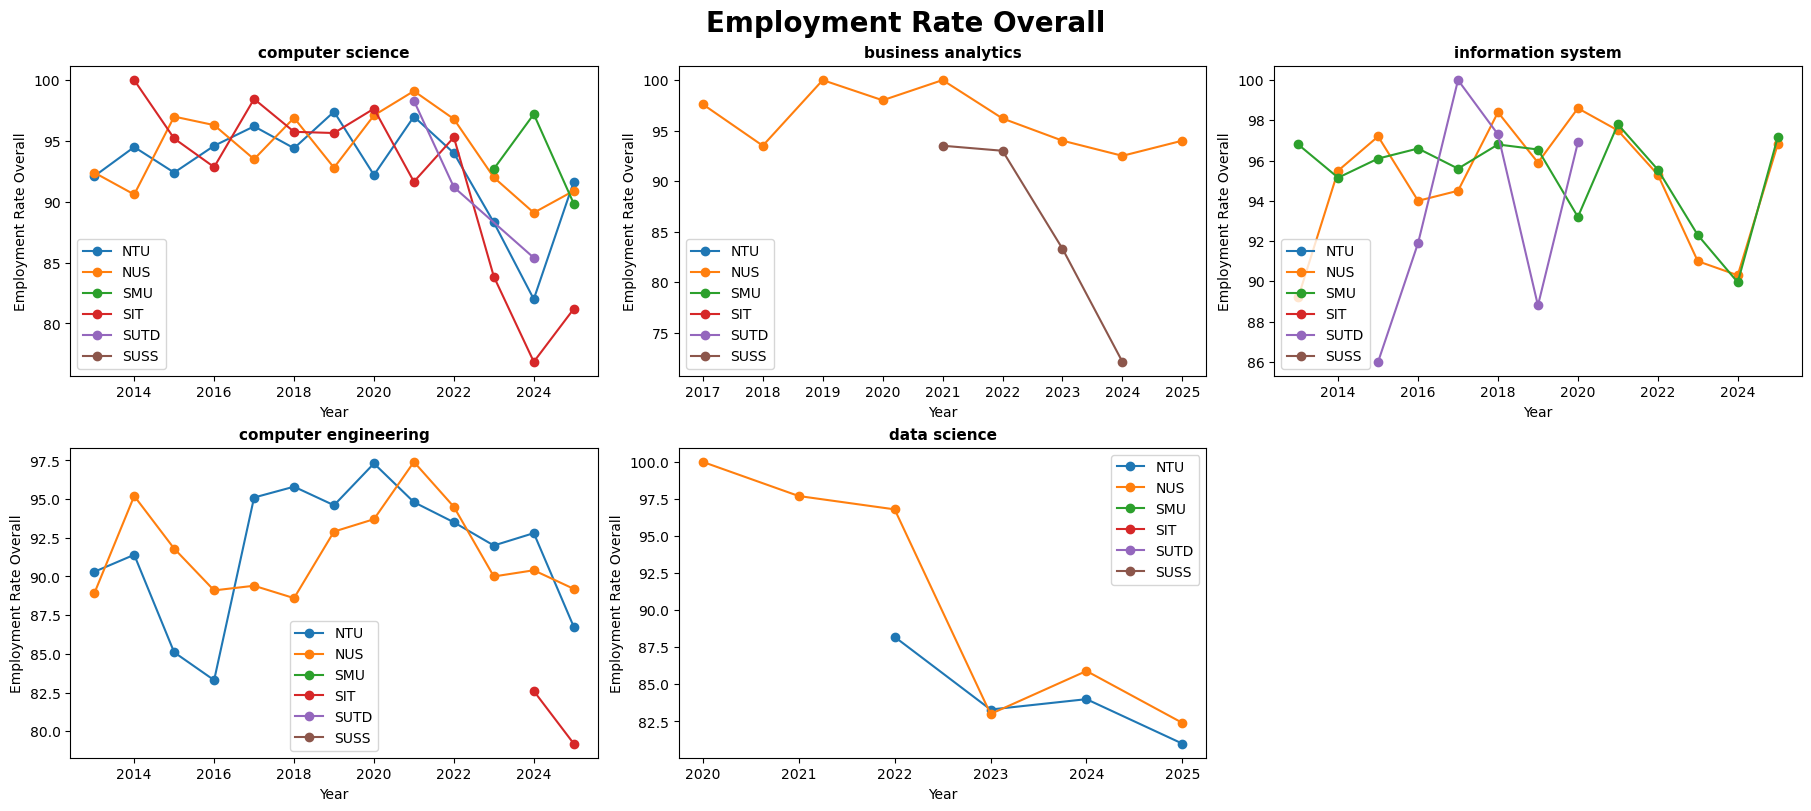

In [8]:
tech_degrees = ['computer science', 'business analytics', 'information system', 'computer engineering', 'data science']
plot_subplots(tech_degrees)

### Insights
- **Generally a tough environment for tech**

From the trends observed, employment rates across most tech-related degrees in Singapore have declined from their peak around 2021. This points to a broader cooling in the tech sector, likely driven by hiring slowdowns, cost-cutting measures, and increasing adoption of AI. The pattern does not appear isolated to Singapore, as similar trends have been observed globally in the tech industry. Overall, the data suggests a shift from a period of rapid expansion to a more cautious and selective hiring environment.

- **Selective degrees suffered the greatest declines**

Among the programmes, SIT Computer Science stands out as a clear outlier with a sharp drop in employment rates. 

Similarly, NUS Data Science and SUSS Business Analytics (who are similar degrees) show significant declines, indicating higher sensitivity to recent market changes. These fields share a focus on data handling and analytical tasks, many of which are increasingly automated by AI tools. As entry-level responsibilities become more efficient and less labour-intensive, demand for junior roles may have weakened, contributing to the observed decline.
  
- **Information systems is the most resilient**

In contrast, Information Systems graduates show relatively stable employment outcomes compared to other tech-related degrees. Although there was a dip following the 2021 peak, employment rates have recovered more strongly in recent years. This resilience may stem from its hybrid curriculum, combining technical knowledge with business applications, allowing graduates to access a wider range of roles.

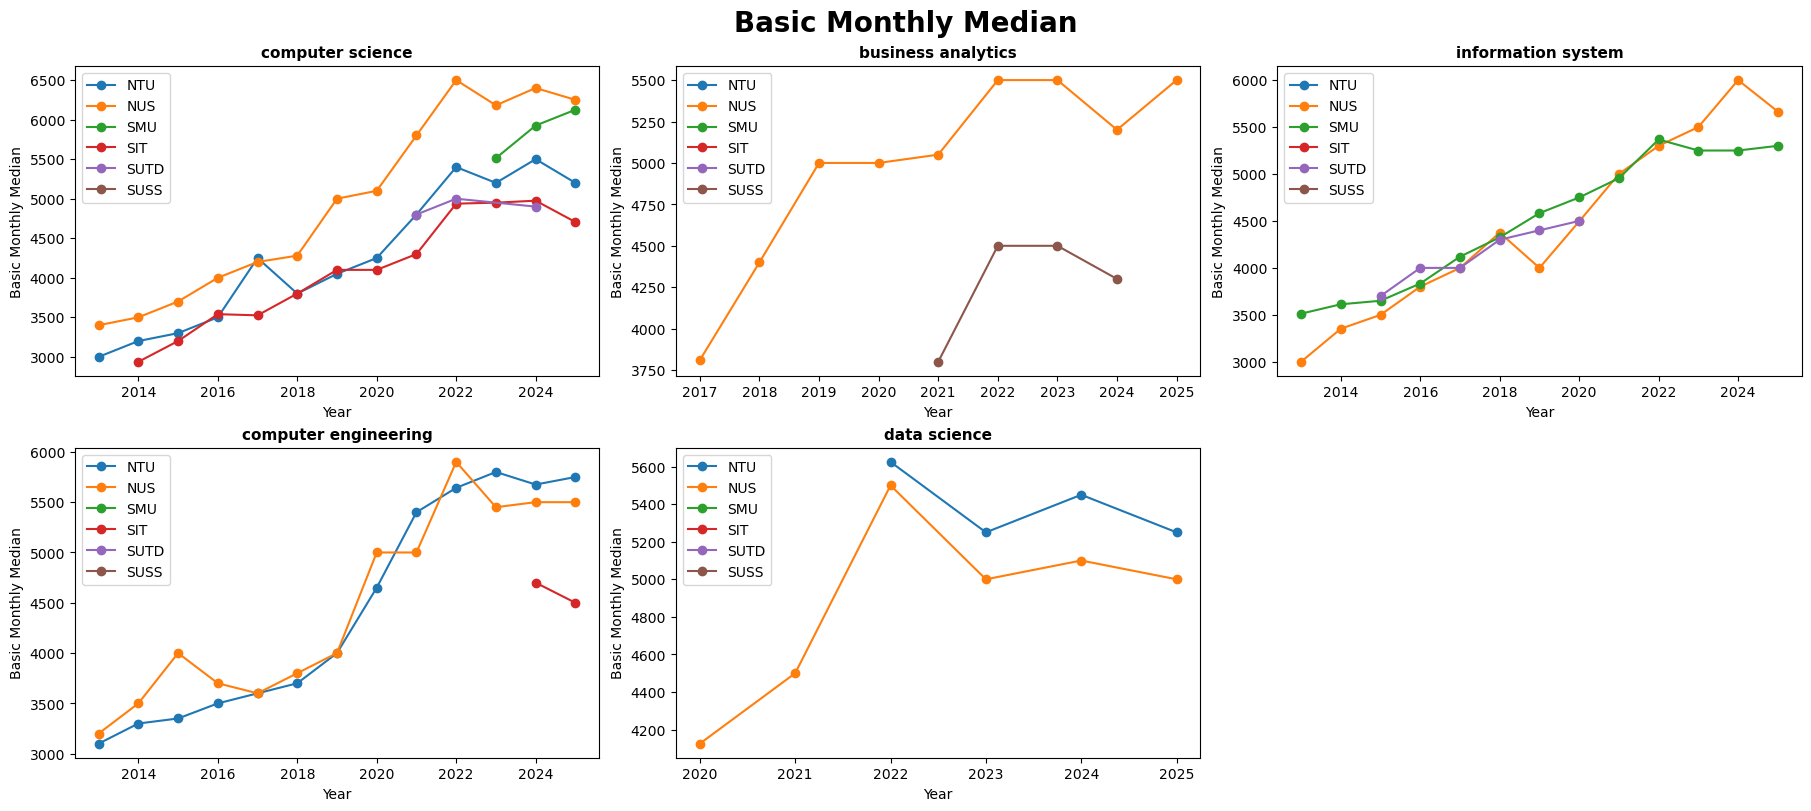

In [9]:
plot_subplots(tech_degrees, metric='basic_monthly_median')

### Insights
- **General increasing trend**

The line charts show a upward trajectory in median salaries across all degrees. This indicates steady structural growth, likely driven by inflation, industry-wide advancements, and higher-value job roles.

- **Salaries seem to have reached a plateau**

From 2021 onwards, the lines begins to flatten, indicating slower growth or stagnation in salaries. This suggests that the pace of salary increases has weakened compared to earlier periods, which may reflect market saturation, economic headwinds, or cooling demand in tech. As a result, salary growth appears to be transitioning from rapid expansion to a more mature phase.

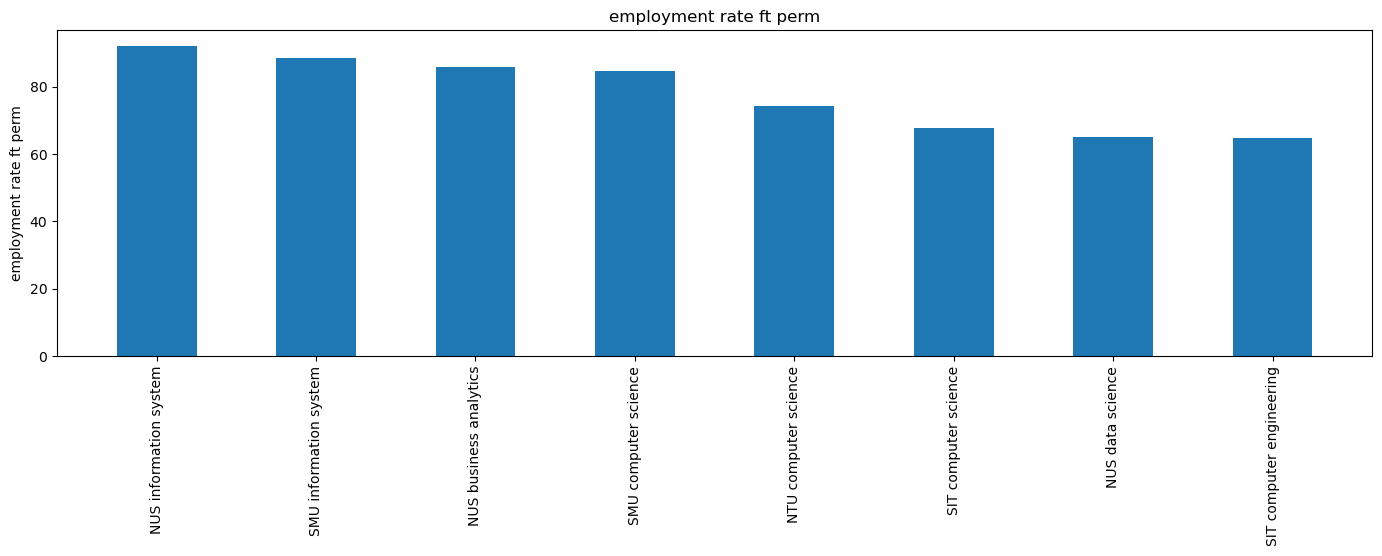

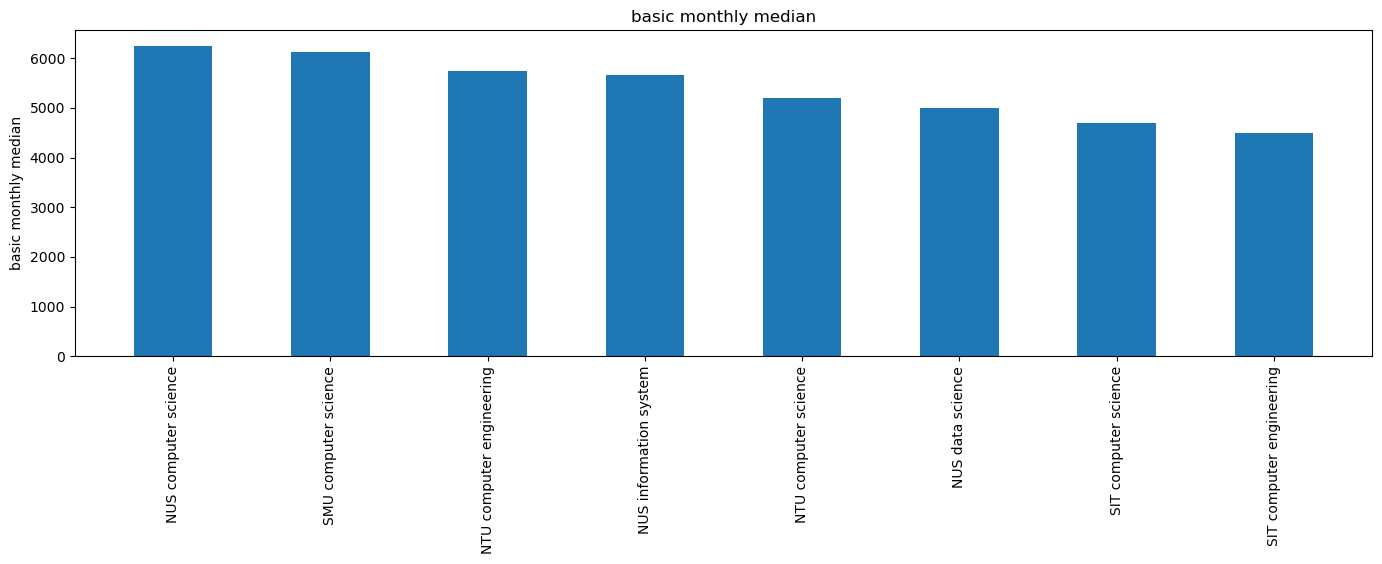

In [10]:
stat_compare(tech_degrees)
stat_compare(tech_degrees, metric='basic_monthly_median')

### Insights
- **Information systems has the best employability**

As aforementioned in previous analyses, infosys degrees impart versatile, in-demand skills that make graduates highly sought after.

- **Median salary is high across all degrees**

Despite variation in employability and ranking, median starting salaries across most degrees remain relatively high, generally above $5,000. This likely suggests the high value added by tech roles and the desire for firms to attract and retain top talents. However, the similarity in median salary masks underlying differences in employment probability and job stability across courses. In other words, while pay levels are strong on average, the risk of not securing a role varies significantly by degree.

### Overall takeaway
- Bleak conditions for the tech sector

# Healthcare jobs

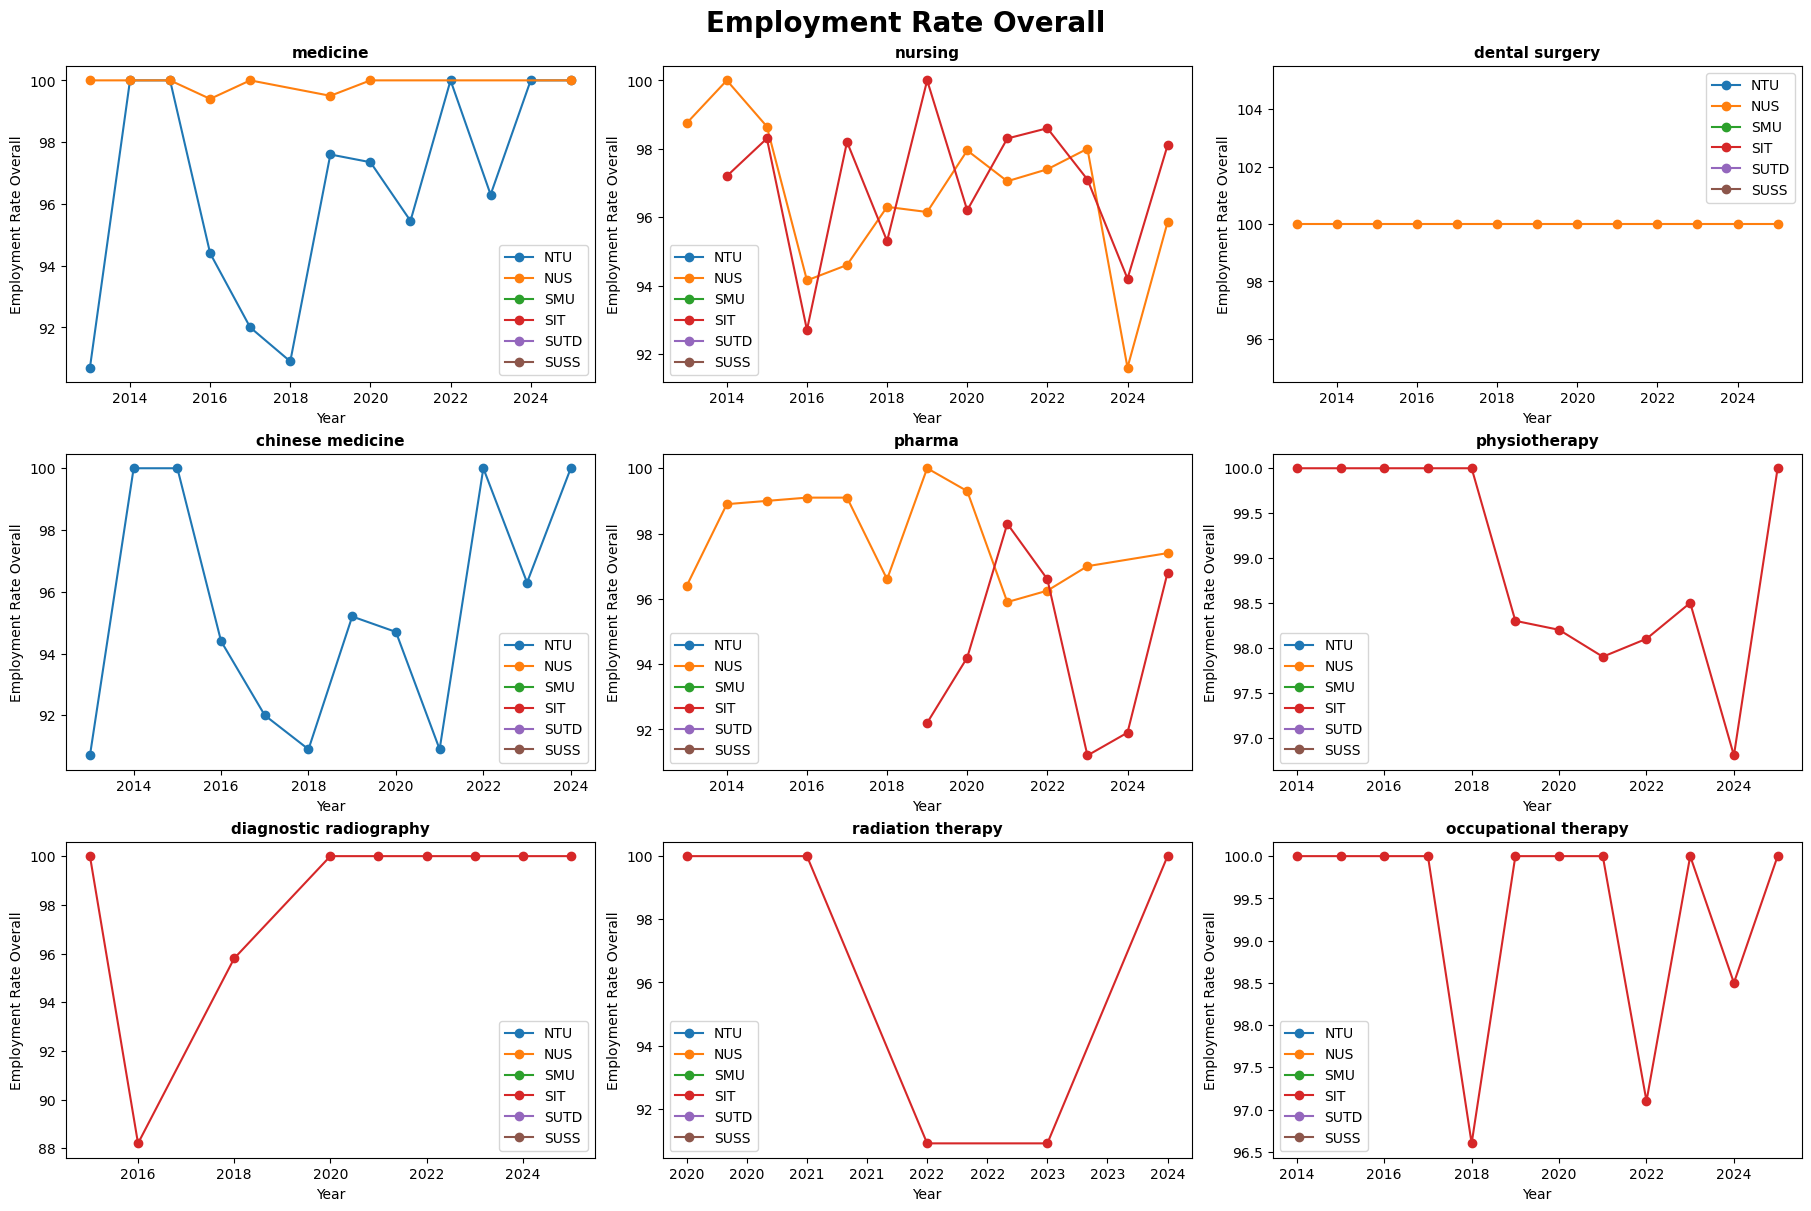

In [11]:
healthcare_degrees = ['medicine', 'nursing', 'dental surgery', 'chinese medicine', 'pharma', 'physiotherapy', 'diagnostic radiography', 'radiation therapy', 'occupational therapy']
plot_subplots(healthcare_degrees)

### Insights
- **Employment remains very strong**

Employment outcomes across most degrees remain very strong and stable overall. This reflects a structurally tight labour market, particularly in healthcare where persistent manpower shortages sustain steady demand. Fields like medicine, nursing, and radiology contribute to lifting overall employability levels due to their consistent hiring needs and low sensitivity to economic cycles.

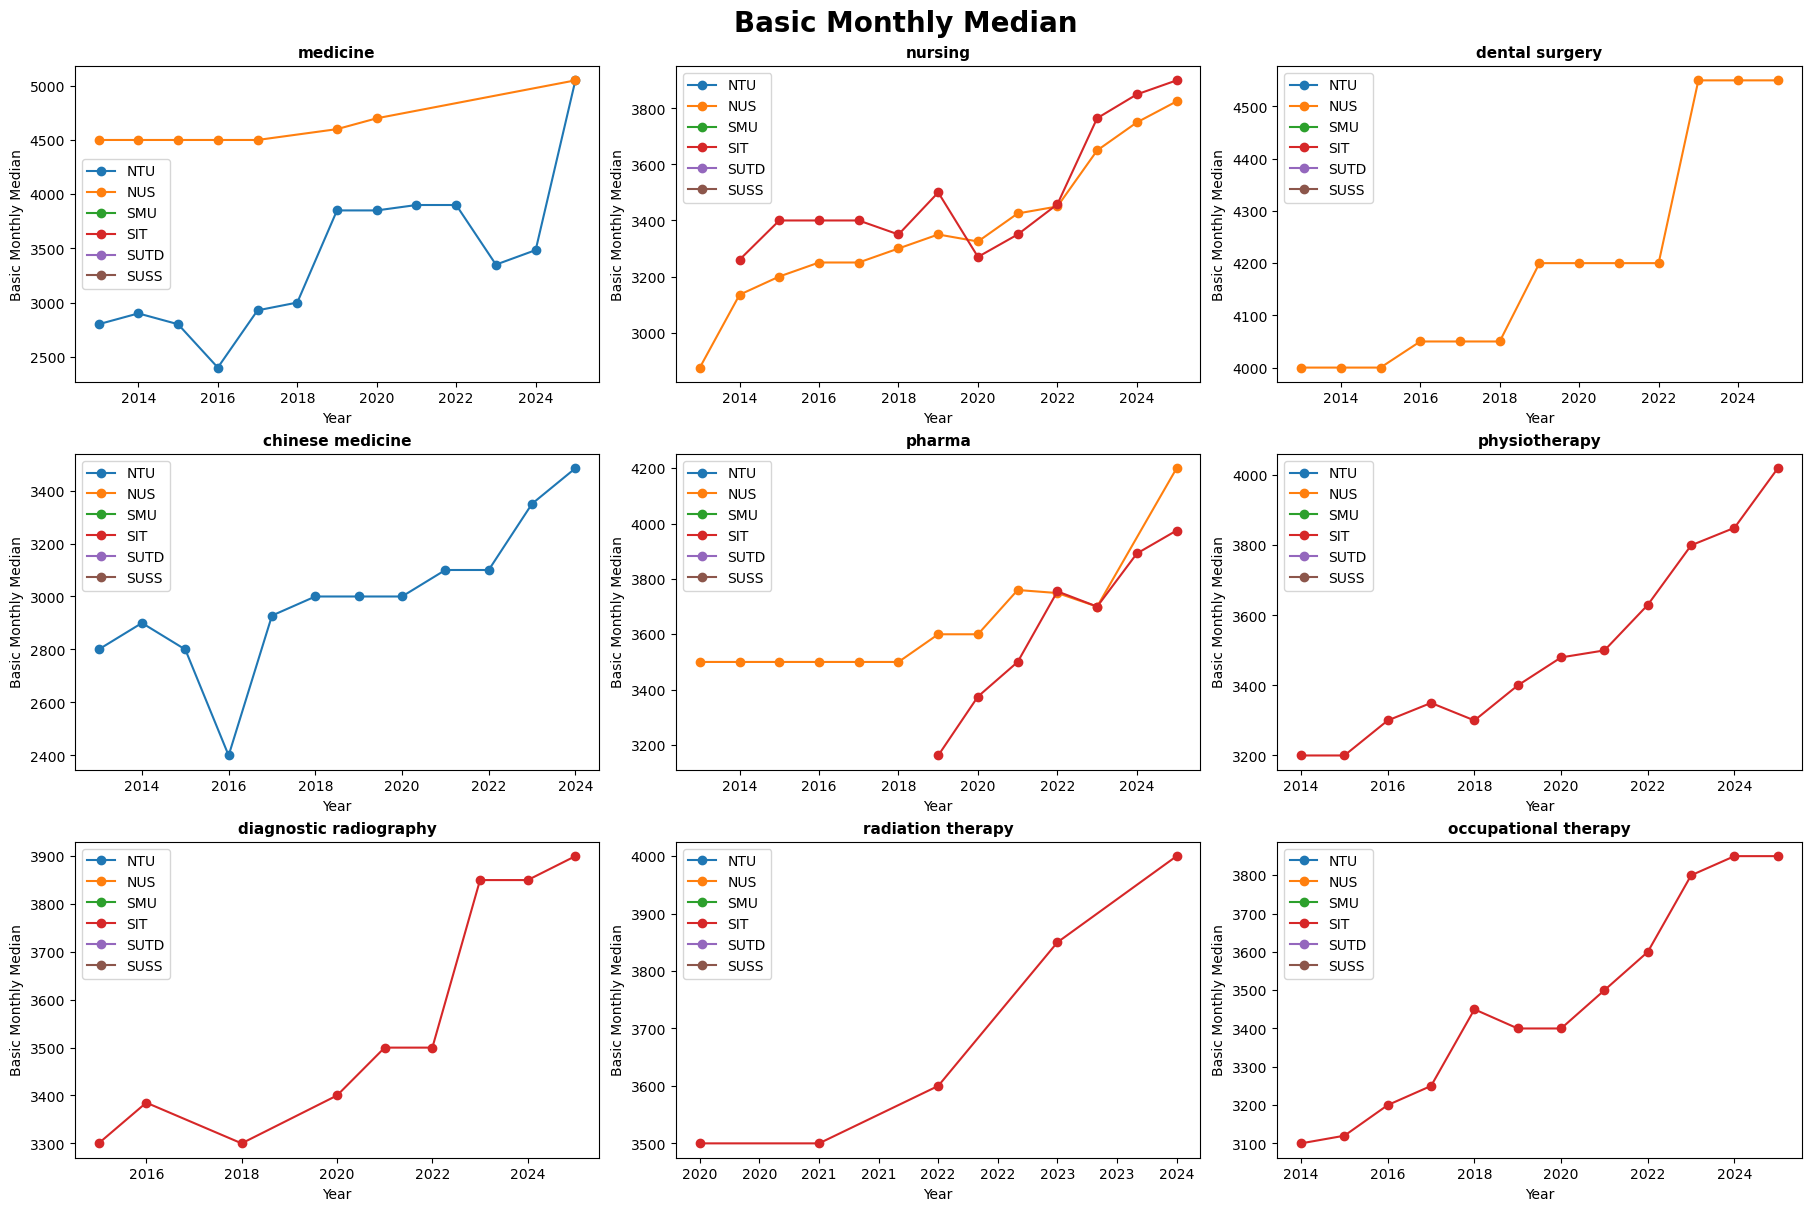

In [12]:
plot_subplots(healthcare_degrees, metric='basic_monthly_median')

### Insights

- **General upward trend**


Across healthcare-related degrees in Singapore, there is a clear and consistent upward trend in median salaries over time, reflecting sustained structural demand for healthcare professionals. This trend is reinforced by long-term demographic pressures, particularly an ageing population that increases the need for medical services, hospital care, and chronic disease management.

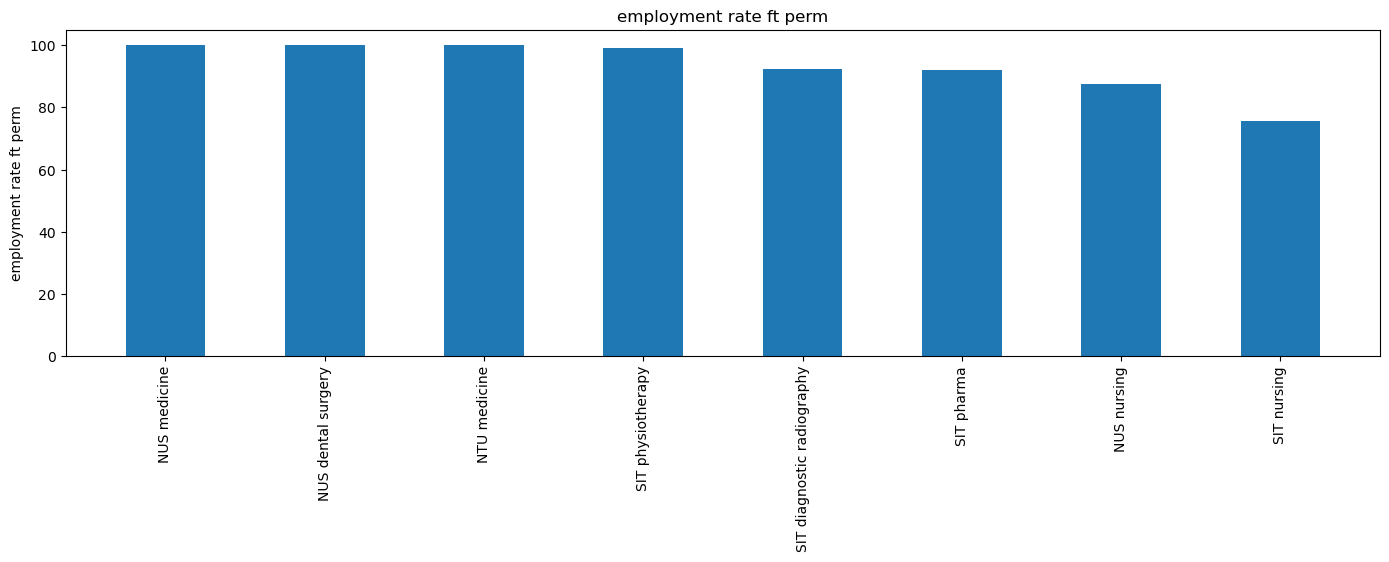

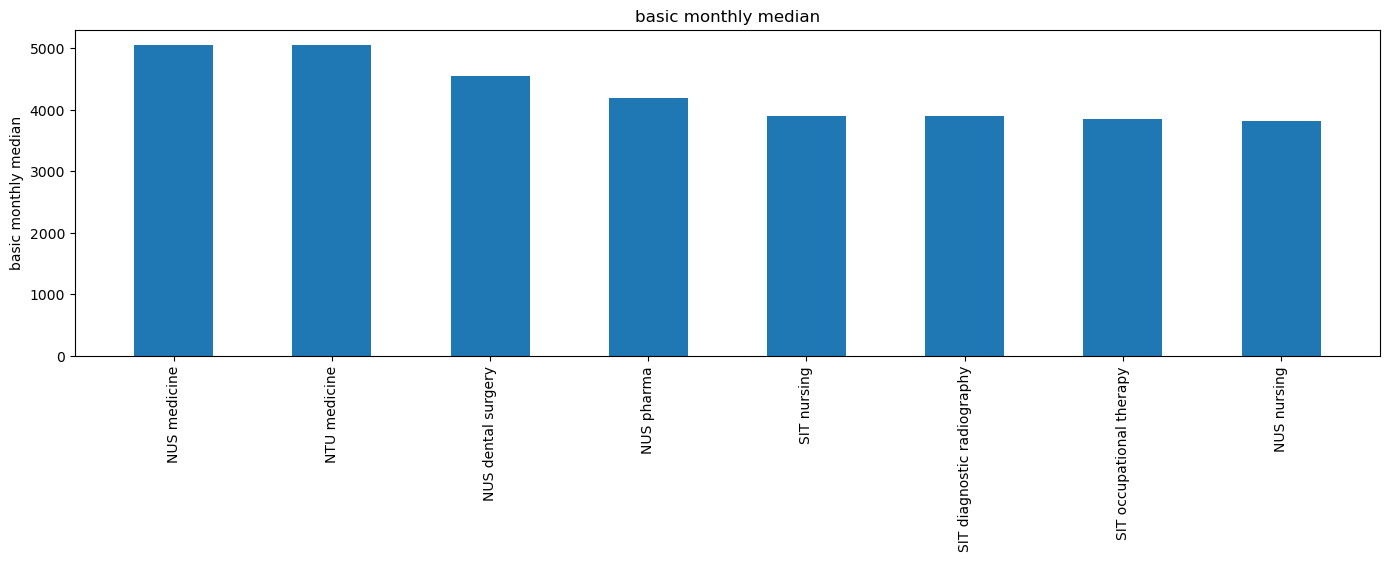

In [13]:
stat_compare(healthcare_degrees)
stat_compare(healthcare_degrees, metric='basic_monthly_median')

### Insights
- **Medicine and dental surgery have the highest employment rate and salary**

Medicine and dental surgery consistently record the highest employment rates and salary outcomes. These degrees sit at the top of both distributions, reflecting their exclusivity, rigorous selection process, and strong demand for specialist medical professionals. Graduates benefit from well-defined career pathways in public and private hospitals and clinics, leading to both high stability and premium compensation.

- **Nursing has the lowest employment rate and salary**

In contrast, nursing shows relatively lower employment rates and salary levels compared to other healthcare fields, although outcomes remain strong in absolute terms. This likely reflects differences in job structure, career progression, and wage ceilings within the healthcare system.

- **Nonetheless nearly all degrees have 100% or near-100% employement rate**

Nearly all healthcare degrees still achieve near-100% or 100% employment rates, indicating that the sector as a whole remains extremely robust. The variation is therefore more about relative ranking within a very strong baseline rather than weak overall performance.

### Overall takeaway
- Extremely robust job market amid strong structural demand

## Business and finance sector

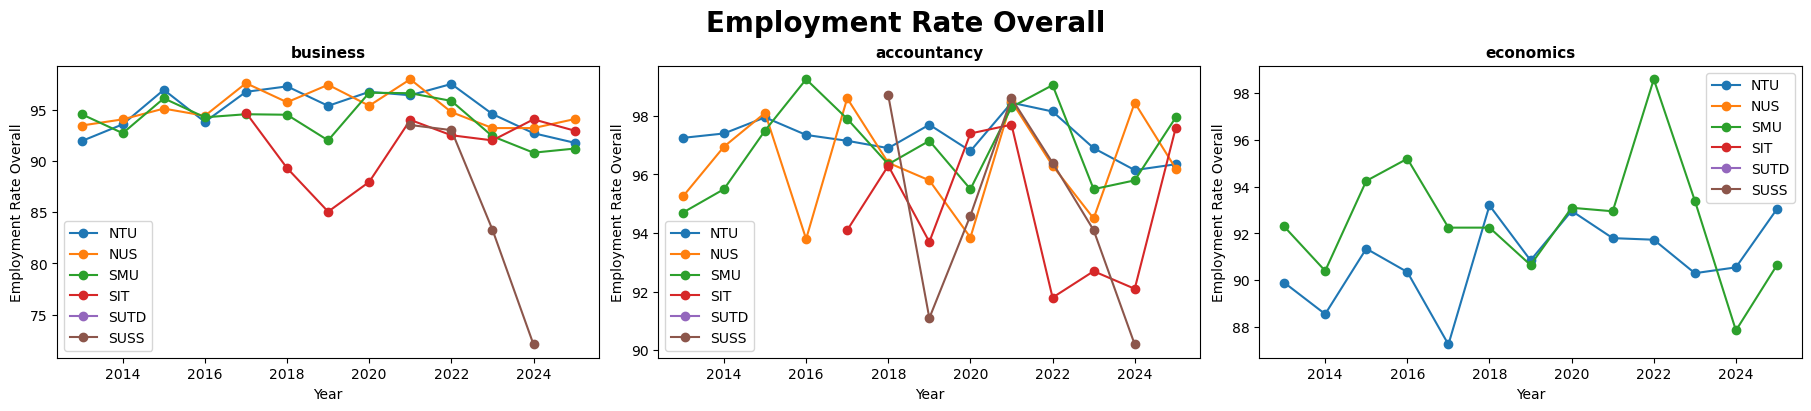

In [14]:
biz_degrees = ['business', 'accountancy', 'economics']
plot_subplots(biz_degrees)

### Insights
- **Employment rates stay stable across all degrees**

Across most business-related degrees in Singapore, employment rates remain broadly stable over time, indicating a generally resilient labour market for business graduates. Most programmes continue to achieve strong job placement outcomes, suggesting that demand for general business skills remains consistent across economic cycles.

- **SUSS business and accountancy is an outlier**

However, business and accountancy programmes from Singapore University of Social Sciences stand out as notable underperformers, showing the largest decline in employment outcomes relative to other universities. While most business degrees maintain steady performance, this outlier suggests greater sensitivity to shifting employer preferences, increased competition, or potential oversupply in certain segments of the job market.

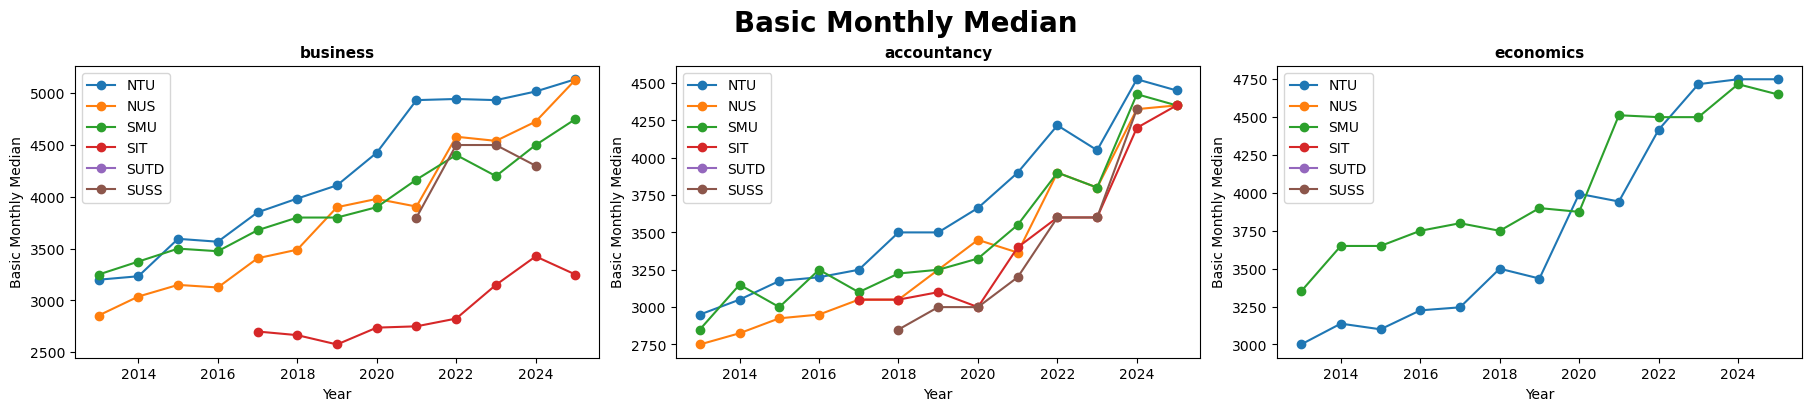

In [15]:
plot_subplots(biz_degrees, metric='basic_monthly_median')

#### Insights
- **General increasing trend**

Likely reflects stable demand for business/finance-related graduates

- **SIT business is an outlier with significantly lower salary and salary growth**

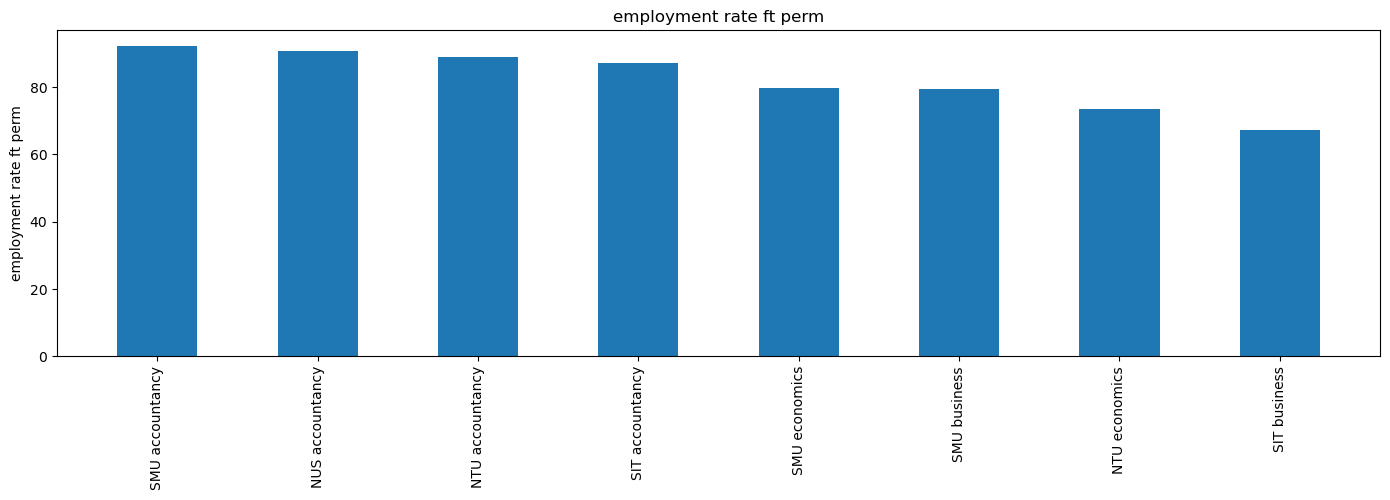

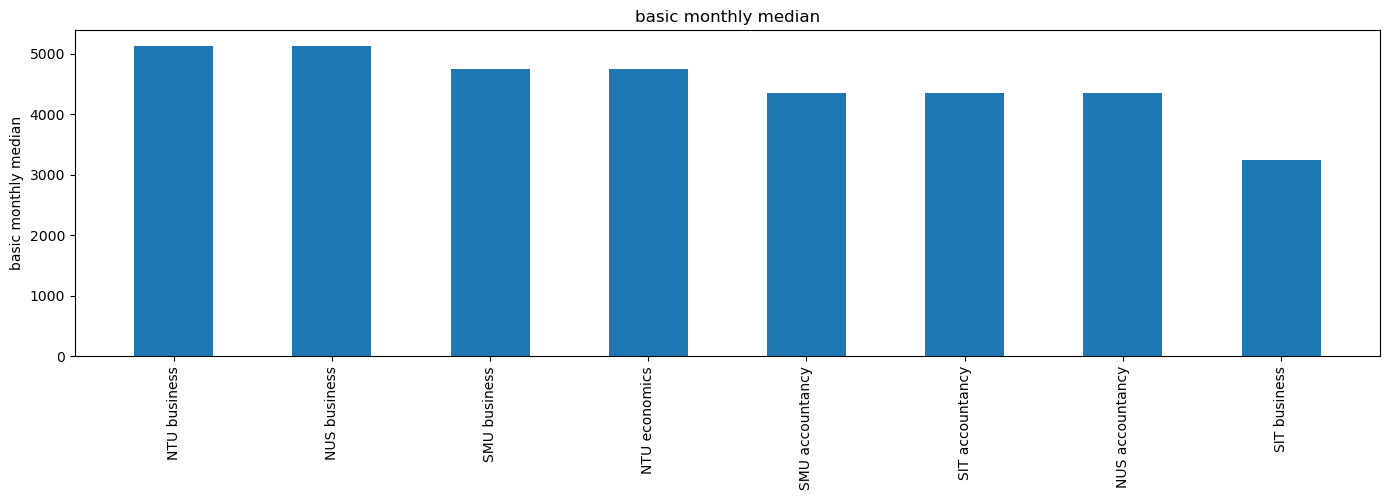

In [16]:
stat_compare(biz_degrees)
stat_compare(biz_degrees, metric='basic_monthly_median')

#### Insights
- **Accountancy is the most employable**

Across universities in Singapore, accountancy consistently records the highest employment rates among business-related degrees. This is likely because accountants perform essential functions such as financial reporting, compliance, and auditing that are required across virtually all industries and businesses.
 
- **However, accountancy salaries rank among the lowest**

Despite strong employability, accountancy graduates tend to receive relatively lower starting salaries compared to other business disciplines. Forums like reddit often point to structural pressures such as offshoring and the influx of lower-cost foreign accounting talent. Many routine accounting functions can be relocated to lower-cost regions, reducing the bargaining power of entry-level accountants in Singapore. At the same time, the globalisation of the profession means firms can tap into a wider labour pool, increasing competition and putting downward pressure on wages. This creates a supply-demand dynamic where jobs remain widely available, but salary growth is constrained. As a result, accountancy offers strong job security and high employability, but comparatively lower starting pay and slower early-career salary progression. 

- **SIT business ranks among the lowest in terms of employability and pay**

Business graduates from SIT appear to underperform in both employment rates and salary outcomes relative to peers. This could reflect differences in employer perception, industry alignment, or competition with graduates from more established universities.

### Overall takeaways
- Employability and salaries are relatively stable

## Science and Engineering

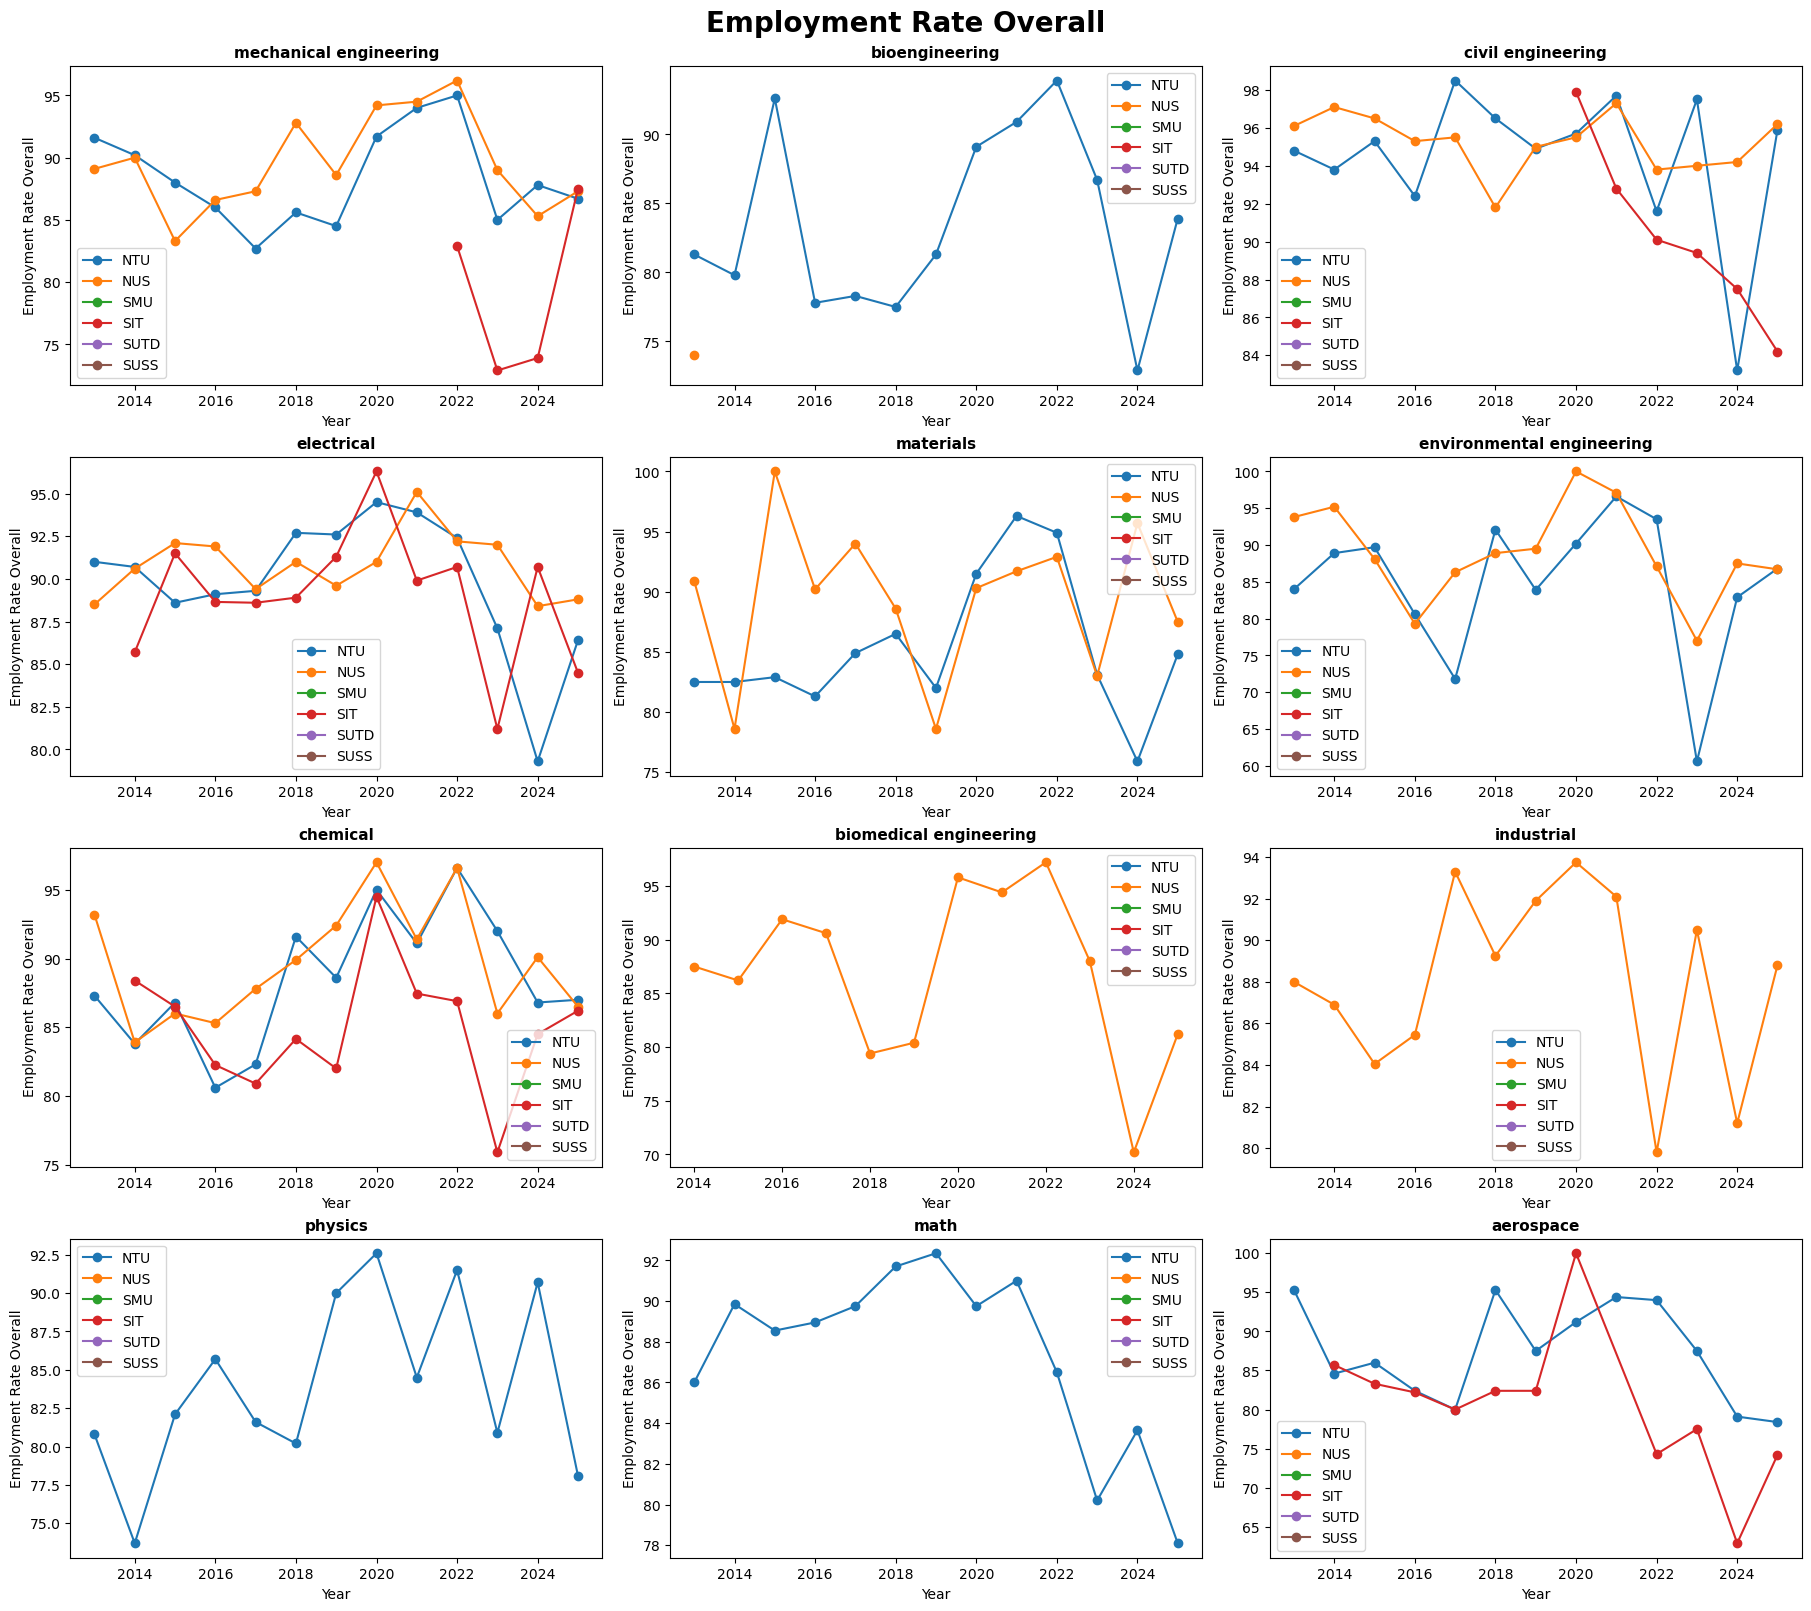

In [17]:
sci_degrees = ['mechanical engineering', 'bioengineering', 'civil engineering', 
               'electrical', 'materials', 'environmental engineering', 
               'chemical', 'biomedical engineering', 'industrial',
              'physics', 'math', 'aerospace']
plot_subplots(sci_degrees)

### Insights
- **Employment rates are volatile**

Employment outcomes for science and engineering degrees in Singapore show noticeable fluctuations. The data exhibits higher variance compared to other fields, with sharper rises and dips across cohorts. This suggests that hiring in these sectors is more sensitive to external conditions, rather than being consistently stable. The observed volatility and uneven recovery point toward a more cyclical nature of the science and engineering job market. Hiring demand in these fields is often tied to broader economic cycles, infrastructure spending, and technological investment trends. During downturns, firms may scale back hiring significantly, while upturns can lead to rapid rebounds. Hence, graduate outcomes are less predictable and more dependent on timing.

- **Uneven recovery in employment rates**

Most science and engineering programmes show signs of recovery in employment rates after recent declines, indicating improving hiring conditions. However, specific courses—such as NTU Mathematics, NUS Physics, and SIT Civil Engineering—remain below previous levels. These outliers suggest uneven recovery across subfields, possibly due to differences in industry demand or alignment with current job market needs. It highlights that recovery is not uniform even within the same broad discipline.

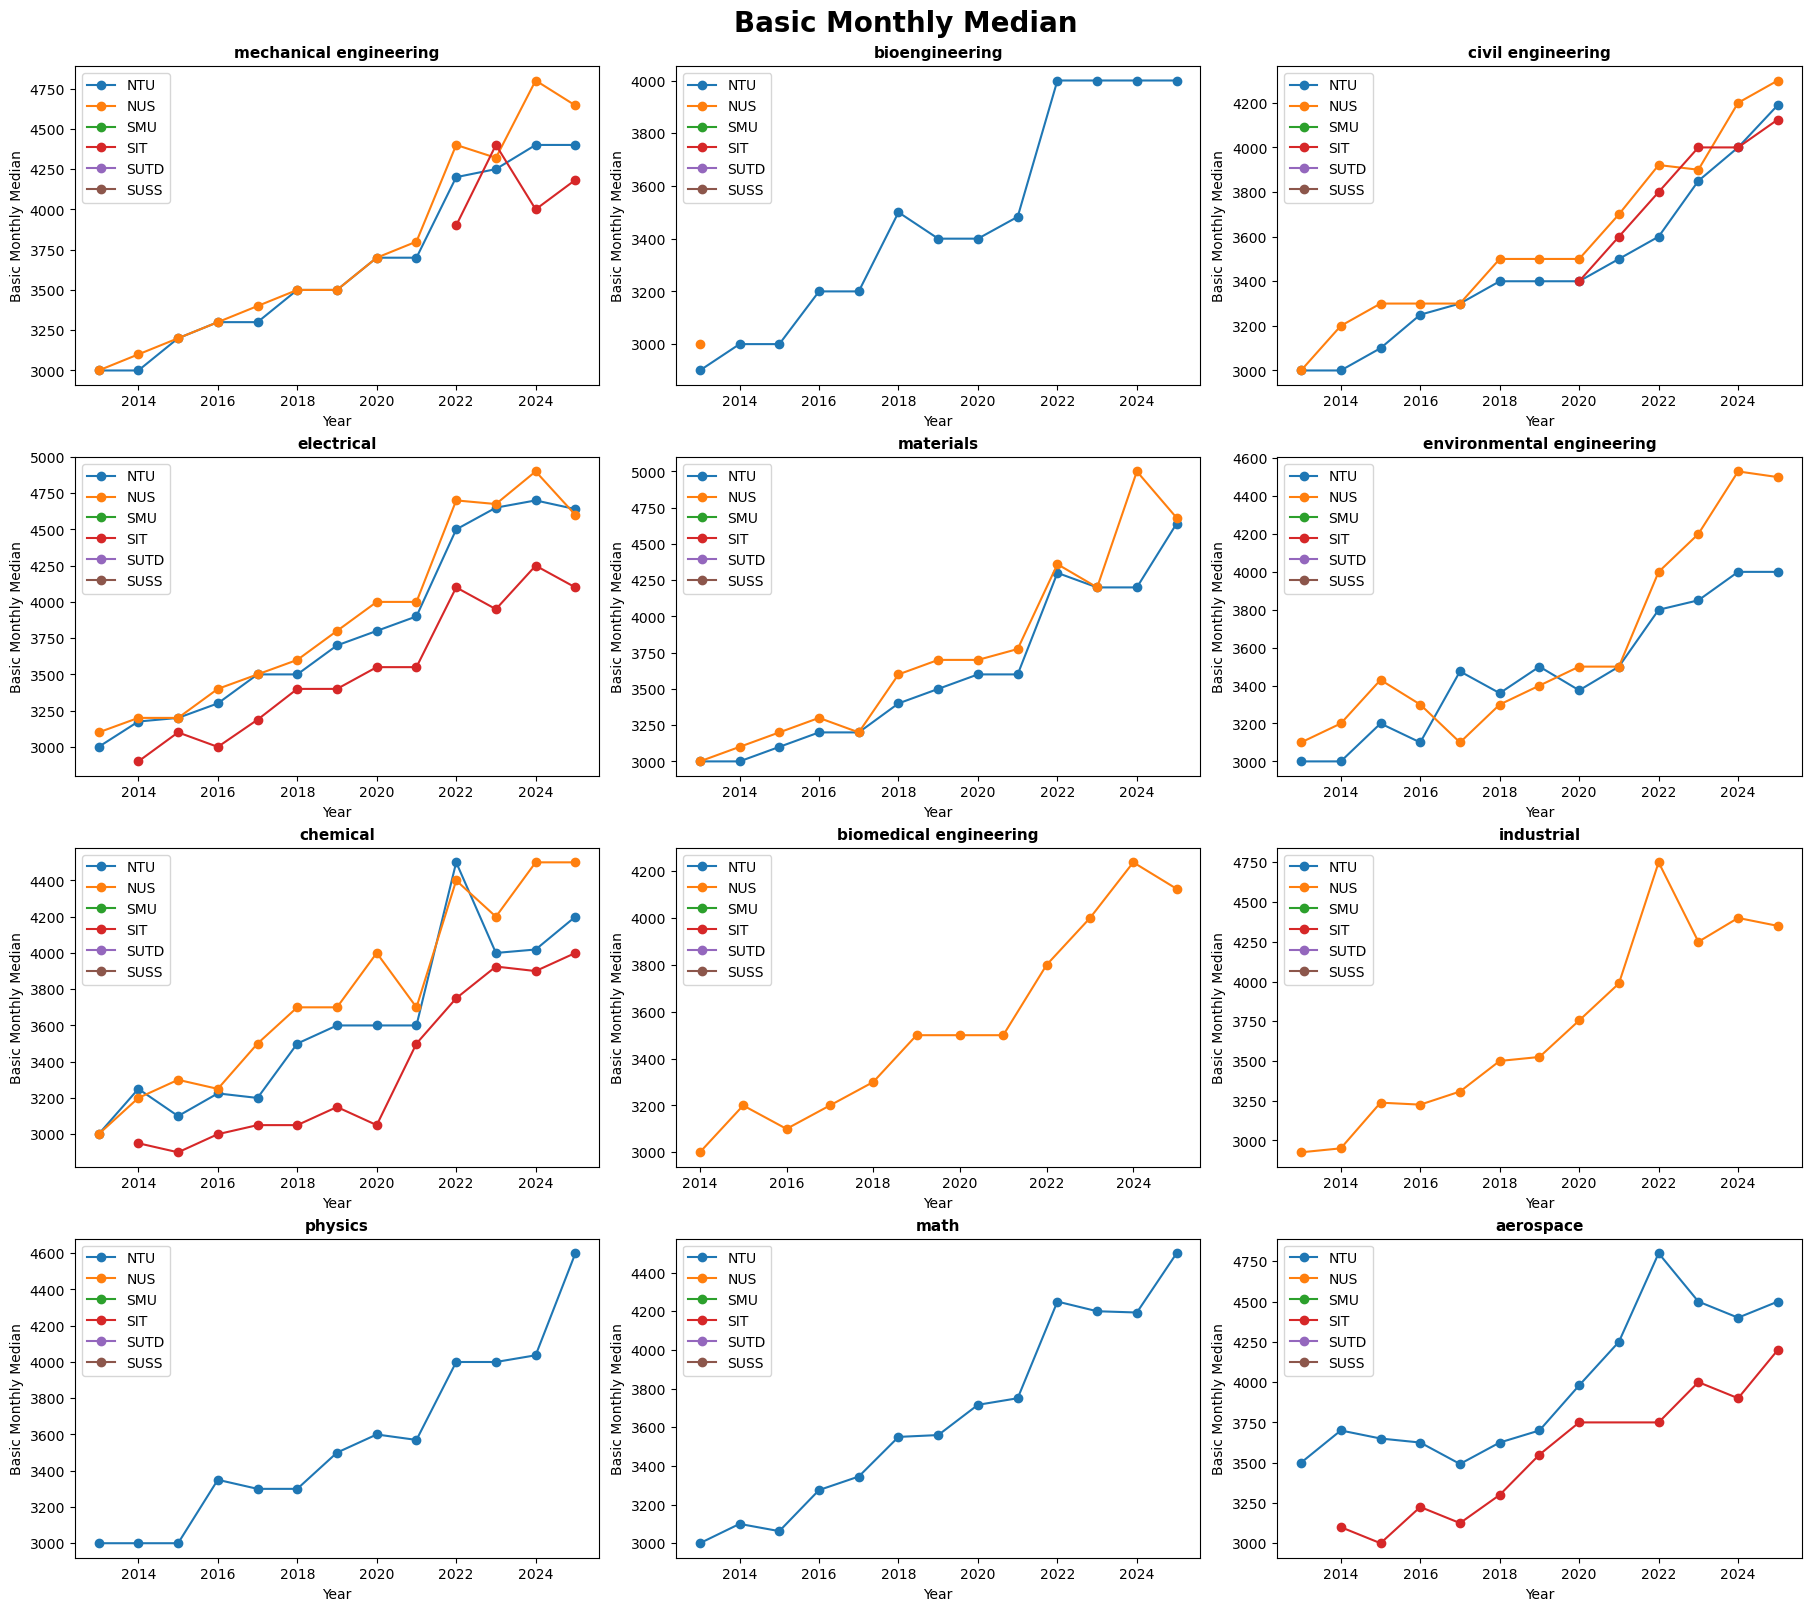

In [18]:
plot_subplots(sci_degrees, metric='basic_monthly_median')

#### Insights
- **Generally increasing salaries across all science and engineering degrees**

The data shows consistent increases in median pay across cohorts, even in years where employment outcomes were more volatile. This suggests that while hiring demand may fluctuate, the value of technical and quantitative skills continues to rise. It appears salary growth in these fields are structurally supported despite cyclical variations in employment.

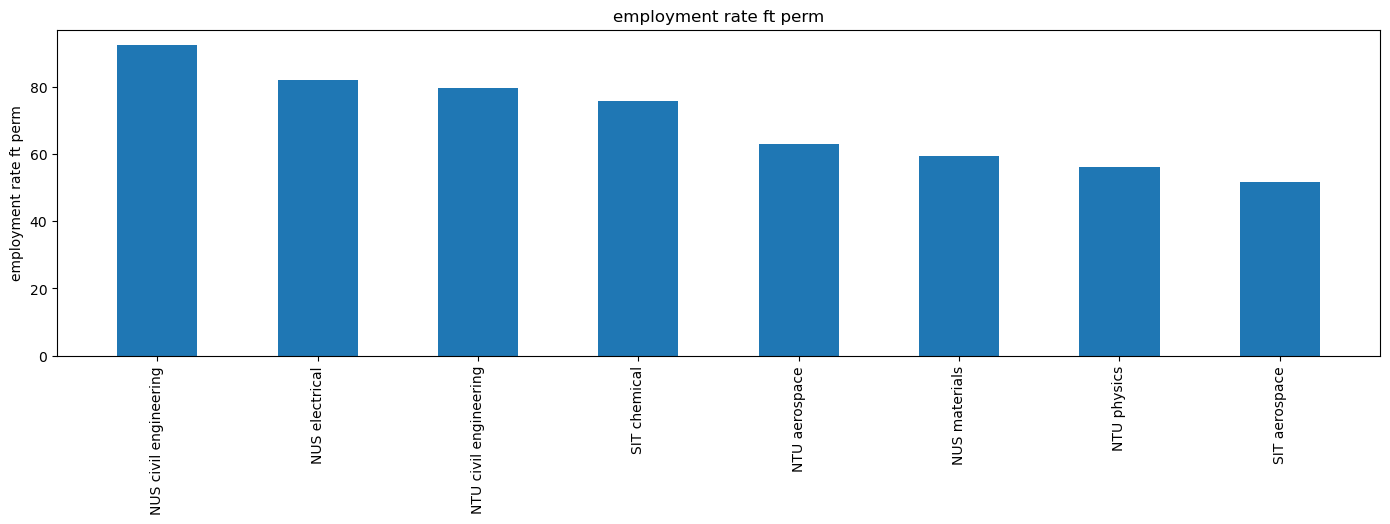

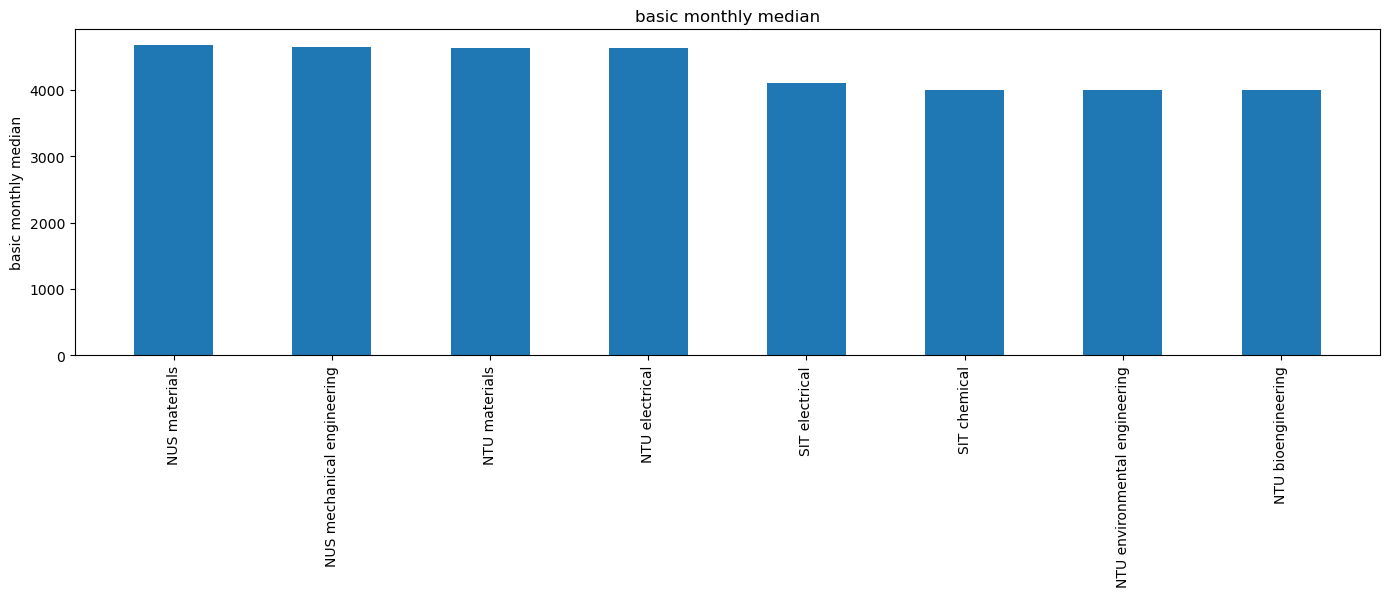

In [22]:
stat_compare(sci_degrees)
stat_compare(sci_degrees, metric='basic_monthly_median')

#### Insights
- **Civil, electrical and chemical engineering are most employable**

The data shows these programmes clustering near the top of the employability distribution, reflecting steady demand in infrastructure, energy, and industrial sectors. Their broad applicability across multiple industries also supports more stable hiring.

- **Niche engineering fields face weaker employment outcomes**

More specialised degrees like materials and aerospace engineering show comparatively lower employment rates. The data suggests a smaller and more concentrated job market, leading to fewer immediate opportunities for graduates. Employment outcomes also appear more sensitive to industry-specific conditions, such as manufacturing cycles or limited local demand. This results in relatively weaker and more variable employability compared to core engineering disciplines.

- **Greater dispersion in employment rates with relatively lower salaries**

In contrast to the tighter salary spread, employment rates show greater variability across different science and engineering disciplines. Some fields achieve near-full employment, while others lag behind, creating a wider distribution. At the same time, overall salary levels tend to be lower compared to top-performing sectors like finance or certain tech roles. This combination suggests that while pay is relatively consistent, job availability is more uneven across the field.

### Overall takeaways
- Cyclical employement outcomes

## Arts and Social Sciences

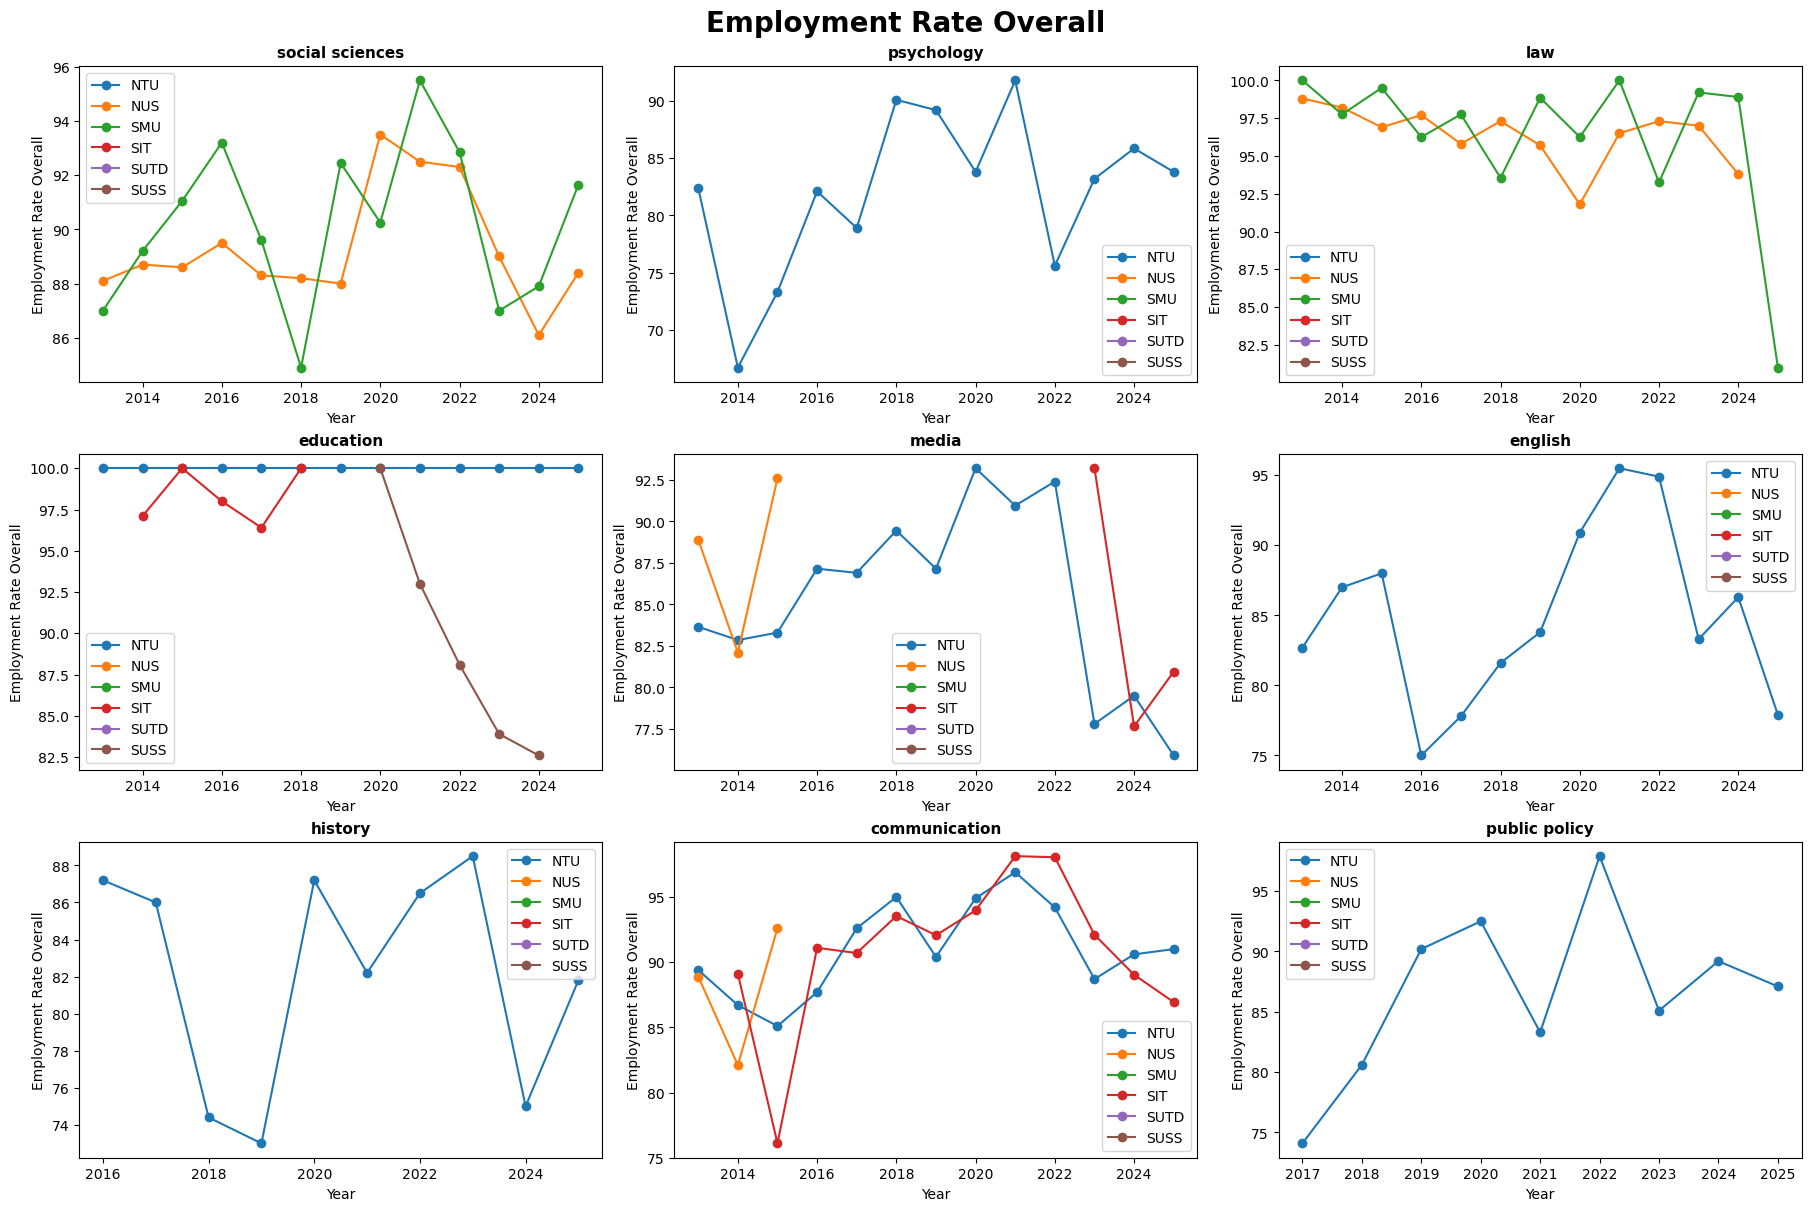

In [23]:
art_degrees = ['social sciences', 'psychology', 'law', 
               'education', 'media', 'english', 
               'history', 'communication', 'public policy']
plot_subplots(art_degrees)

### Insights
- **Broad decline in employment rates post-2021**

Employment rates show a noticeable decline starting from 2021 onwards. The data suggests a shift from peak hiring conditions, likely driven by post-pandemic recovery to a more constrained labour market. This downward movement is observed across several disciplines, indicating a broad-based cooling rather than isolated weakness. This likely results in a more competitive job environment for recent graduates.

- **Sharpest declines in specific programmes**

The largest drops are concentrated in media-related degrees at NTU and SIT, as well as in law at SMU and education at SUSS. This suggests higher sensitivity to shifts in industry demand or hiring cycles. The magnitude of change indicates that certain specialised or sector-dependent fields may be more vulnerable during downturns.

- **NTU education is most robust**

In contrast to SUSS education, NTU education employment rates remain consistently at or near 100%, indicating strong and stable demand for its graduates. This is likely because students in NTU and trained under the National Institute of Education (NIE), where careers in MOE are mapped out and are almost guaranteed for graduates. Moreover, demand for MOE teachers is relatively insensitive to economic conditions and hence are remain stable over time.

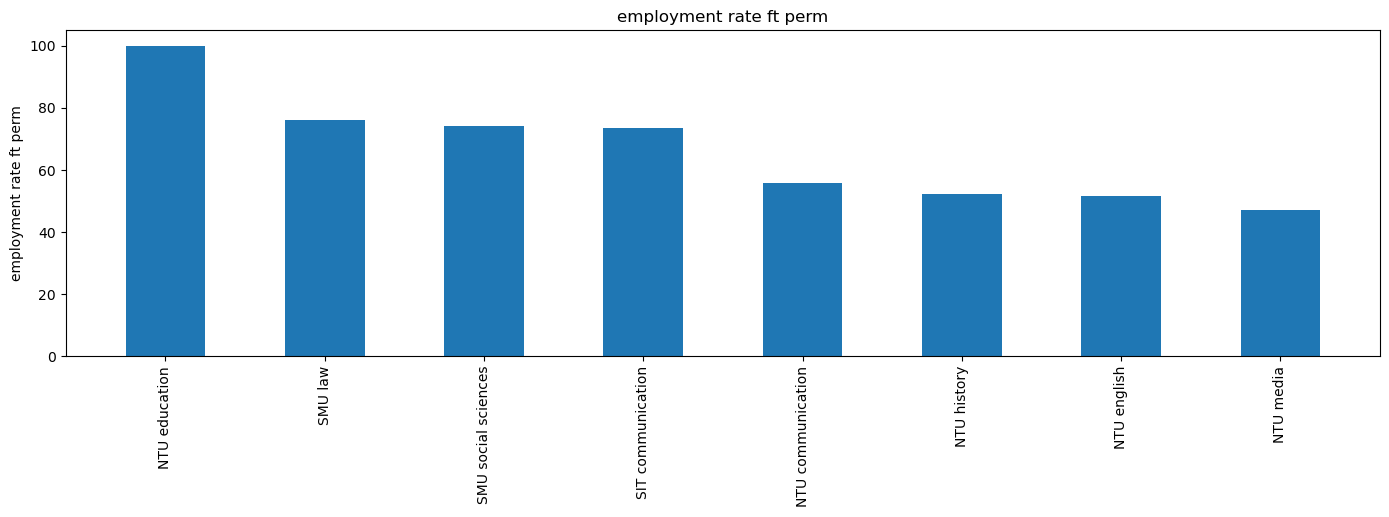

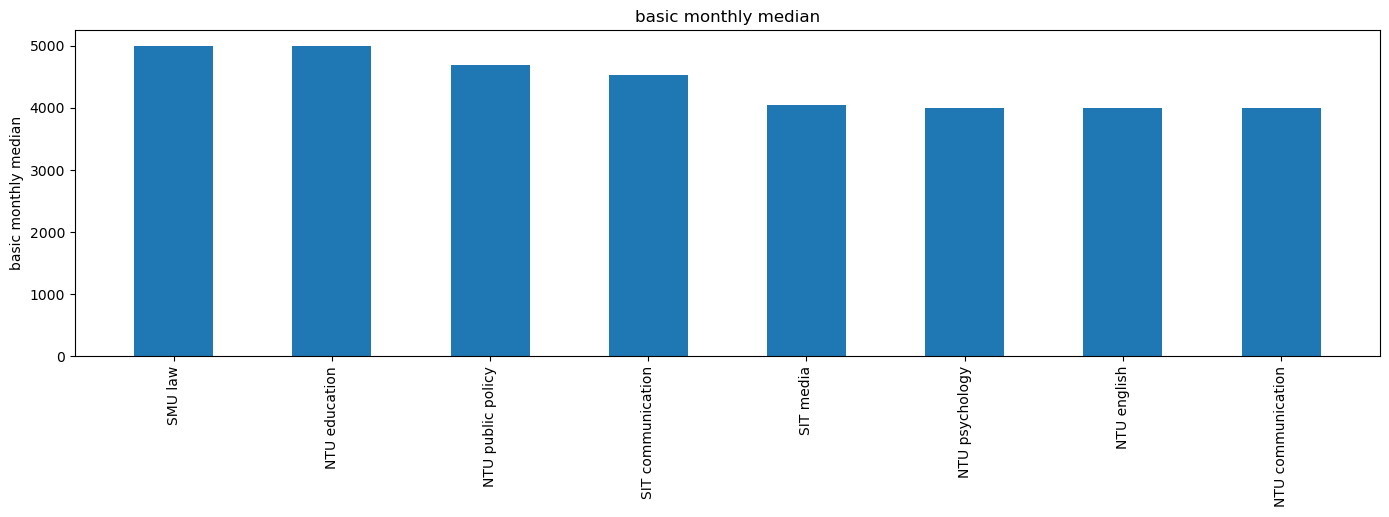

In [24]:
stat_compare(art_degrees)
stat_compare(art_degrees, metric='basic_monthly_median')

### Insights
- **NTU Education and SMU Law lead in employability and pay**

The data shows strong clustering at near-full employment alongside relatively high median pay. This reflects structured career pathways, strong institutional pipelines, and sustained demand in essential sectors like education and legal services. Graduates from these programmes enjoy both high job security and attractive compensation.

- **Niche degrees show weaker employment and salary outcomes**

Degrees such as English, media, and communication tend to rank lower in both employability and salary metrics. The data indicates lower employment rates and wider variability, suggesting less stable and more competitive job markets. These fields often lead to less direct career pathways and depend more on industry conditions like media demand or creative sector growth. Furthermore, the creative arts and media scene in Singapore remain relatively undeveloped, leaving lesser opportunities for graduates from niche arts degrees.

### Overall takeaways
- Secure employment for selective degrees, weakening environment for niche degrees

# Conclusion
### Overall graduate job market
- Acute deterioration in employability
- Salaries continue to grow. This is good for those who manage to secure and retain employment.

### Overall market conditions by industry
- Tech: challenging times
- Healthcare: resilient
- Business and finance: stable
- Science and Engineering: volatile
- Arts and Social Sciences: wide disparity within the industry